<a href="https://colab.research.google.com/github/olya-mashtalyar/statistical-practicum/blob/main/Proekt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Описание датасета
https://www.kaggle.com/datasets/andrewmvd/sp-500-stocks/data

В проекте используются три файла с данными об индексе S&P 500 и входящих в него компаниях за период 2014-2024 годов.

### 1. sp500_index.csv — данные индекса S&P 500

Date — дата торгов \
S&P500 — цена закрытия индекса

 ### 2. sp500_companies.csv — информация о компаниях

Symbol — тикер (краткое обозначение акции) \
Shortname — краткое название компании \
Longname — полное название компании \
Sector — сектор экономики \
Industry — отрасль \
Weight — вес компании в индексе

 ### 3. sp500_stocks.csv — исторические данные по акциям

Date — дата торгов \
Symbol — тикер акции \
Adj Close — скорректированная цена закрытия \
Close— цена закрытия \
High — максимальная цена за день \
Low — минимальная цена за день \
Open — цена открытия \
Volume — объем торгов

   # Постановка задачи
1. Провести разведочный анализ данных (EDA) индекса S&P 500

2. Проверить, проявляется ли в данных эффект кластеризации волатильности (ARCH-эффект)

3. Построить и сравнить модели GARCH для прогнозирования волатильности:
  - GARCH(1,1) с нормальным распределением
   - GARCH(1,1) с t-распределением Стьюдента
   - EGARCH(1,1)

4. Выбрать лучшую модель на основе критериев AIC и BIC

5. Выполнить прогноз волатильности индекса S&P 500 на 30 торговых дней вперед

### Используемые метрики:

- QLIKE
- MSE

Основной метрикой выступает QLIKE (Quasi-Likelihood loss), которая основана на квази-правдоподобии и обладает устойчивостью к ошибкам спецификации модели.

Дополнительно используется среднеквадратичная ошибка (MSE), рассчитываемая между прогнозной условной дисперсией и реализованной волатильностью. Эта метрика позволяет количественно оценить отклонение прогноза от наблюдаемых значений, однако является более чувствительной к выбросам.

Для выбора оптимальной модели будут использоваться информационные критерии Акаике (AIC) и Байесовский информационный критерий (BIC). Оба критерия основаны на максимизации функции правдоподобия с добавлением штрафа за сложность модели.


In [1]:
!pip install arch -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 4.9 MB/s eta 0:00:00


In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from datetime import datetime
from arch import arch_model
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

In [4]:
from google.colab import drive
drive.mount('/content/drive')
companies_df = pd.read_csv('/content/drive/MyDrive/sp500_companies.csv')
index_df = pd.read_csv('/content/drive/MyDrive/sp500_index.csv')
index_df['Date'] = pd.to_datetime(index_df['Date'])
index_df = index_df.sort_values('Date').reset_index(drop=True)
chunks = []
for chunk in pd.read_csv('/content/drive/MyDrive/sp500_stocks.csv', chunksize=100000, low_memory=False):
    chunks.append(chunk)
stocks_df = pd.concat(chunks, ignore_index=True)

Mounted at /content/drive


In [5]:
def data_info(data):
    data.info()
    print()
    print('Доля пропущенных значений:')
    mis_values_visit = data.isnull().sum().to_frame('missing_values')
    mis_values_visit['Доля'] = round(data.isna().mean(),2)
    print(mis_values_visit.sort_values(by='Доля', ascending=False))
    print()

    display(data.head())

data_info(index_df)
data_info(companies_df)
data_info(stocks_df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2517 entries, 0 to 2516
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    2517 non-null   datetime64[ns]
 1   S&P500  2517 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 39.5 KB

Доля пропущенных значений:
        missing_values  Доля
Date                 0   0.0
S&P500               0   0.0



,Date,S&P500
0,2014-12-22,2078.54
1,2014-12-23,2082.17
2,2014-12-24,2081.88
3,2014-12-26,2088.77
4,2014-12-29,2090.57


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 502 entries, 0 to 501
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Exchange             502 non-null    object 
 1   Symbol               502 non-null    object 
 2   Shortname            502 non-null    object 
 3   Longname             502 non-null    object 
 4   Sector               502 non-null    object 
 5   Industry             502 non-null    object 
 6   Currentprice         502 non-null    float64
 7   Marketcap            502 non-null    int64  
 8   Ebitda               473 non-null    float64
 9   Revenuegrowth        499 non-null    float64
 10  City                 502 non-null    object 
 11  State                482 non-null    object 
 12  Country              502 non-null    object 
 13  Fulltimeemployees    493 non-null    float64
 14  Longbusinesssummary  502 non-null    object 
 15  Weight               502 non-null    flo

,Exchange,Symbol,Shortname,Longname,Sector,Industry,Currentprice,Marketcap,Ebitda,Revenuegrowth,City,State,Country,Fulltimeemployees,Longbusinesssummary,Weight
0,NMS,AAPL,Apple Inc.,Apple Inc.,Technology,Consumer Electronics,254.49,3846819807232,1.346610e+11,0.061,Cupertino,CA,United States,164000.0,"Apple Inc. designs, manufactures, and markets ...",0.069209
1,NMS,NVDA,NVIDIA Corporation,NVIDIA Corporation,Technology,Semiconductors,134.70,3298803056640,6.118400e+10,1.224,Santa Clara,CA,United States,29600.0,NVIDIA Corporation provides graphics and compu...,0.059350
2,NMS,MSFT,Microsoft Corporation,Microsoft Corporation,Technology,Software - Infrastructure,436.60,3246068596736,1.365520e+11,0.160,Redmond,WA,United States,228000.0,Microsoft Corporation develops and supports so...,0.058401
3,NMS,AMZN,"Amazon.com, Inc.","Amazon.com, Inc.",Consumer Cyclical,Internet Retail,224.92,2365033807872,1.115830e+11,0.110,Seattle,WA,United States,1551000.0,"Amazon.com, Inc. engages in the retail sale of...",0.042550
4,NMS,GOOGL,Alphabet Inc.,Alphabet Inc.,Communication Services,Internet Content & Information,191.41,2351625142272,1.234700e+11,0.151,Mountain View,CA,United States,181269.0,Alphabet Inc. offers various products and plat...,0.042309


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1891536 entries, 0 to 1891535
Data columns (total 8 columns):
 #   Column     Dtype  
---  ------     -----  
 0   Date       object 
 1   Symbol     object 
 2   Adj Close  float64
 3   Close      float64
 4   High       float64
 5   Low        float64
 6   Open       float64
 7   Volume     float64
dtypes: float64(6), object(2)
memory usage: 115.5+ MB

Доля пропущенных значений:
           missing_values  Доля
Close             1273705  0.67
Adj Close         1273705  0.67
Low               1273705  0.67
High              1273705  0.67
Open              1273705  0.67
Volume            1273705  0.67
Date                    0  0.00
Symbol                  0  0.00



,Date,Symbol,Adj Close,Close,High,Low,Open,Volume
0,2010-01-04,MMM,NaN,NaN,NaN,NaN,NaN,NaN
1,2010-01-05,MMM,NaN,NaN,NaN,NaN,NaN,NaN
2,2010-01-06,MMM,NaN,NaN,NaN,NaN,NaN,NaN
3,2010-01-07,MMM,NaN,NaN,NaN,NaN,NaN,NaN
4,2010-01-08,MMM,NaN,NaN,NaN,NaN,NaN,NaN


**1.  Данные индекса S&P 500 (index_df)** \
Данные за период 2014-2024 гг., 2517 наблюдений. Пропусков нет. Данные готовы к анализу, обработка не требуется.

**2. Данные о компаниях (companies_df)** \
502 компании, 16 признаков. Пропуски есть в Ebitda (6%), State (4%), Fulltimeemployees (2%), Revenuegrowth (1%). Используемые признаки (Symbol, Shortname, Sector, Weight) пропусков не имеют. Неиспользуемые признаки удалим.

**3. Данные по акциям (stocks_df)** \
 Обнаружено 67% пропусков в столбцах с ценами и объемами. Причина — разные акции имеют разную историю торгов. Строки с пропусками удалим, так как это дни без торгов.

**Решения по обработке**\
index_df — без изменений \
companies_df — удалить неиспользуемые признаки \
stocks_df — удалить строки с пропущенными ценами

In [6]:
cols_to_drop = ['Exchange', 'Currentprice', 'Marketcap', 'Ebitda', 'Revenuegrowth',
                'Fulltimeemployees', 'Longbusinesssummary', 'City', 'State', 'Country']
companies_df = companies_df.drop(columns=[col for col in cols_to_drop if col in companies_df.columns])

stocks_df = stocks_df.dropna(subset=['Close', 'High', 'Low', 'Open'])
stocks_df['Date'] = pd.to_datetime(stocks_df['Date'])

In [7]:
index_df['Return'] = index_df['S&P500'].pct_change()
print("\n Статистика индекса ")
print(index_df[['S&P500', 'Return']].describe())


 Статистика индекса 
            S&P500       Return
count  2517.000000  2516.000000
mean   3346.351605     0.000480
std    1078.204274     0.011223
min    1829.080000    -0.119841
25%    2428.370000    -0.003773
50%    2999.910000     0.000639
75%    4199.120000     0.005748
max    6090.270000     0.093828


За период с 2014 по 2024 год (2516 торговых дней) средняя дневная доходность индекса составила 0.048% при стандартном отклонении 1.12%. Годовая волатильность оценивается в 17.8%.

Распределение доходностей демонстрирует отклонение от нормального:

Минимальная доходность (-11.98% в день) по модулю превышает максимальную (+9.38%), что указывает на отрицательную асимметрию и эффект рычага

Медиана (0.064%) превышает среднее (0.048%), подтверждая смещение распределения влево

Межквартильный размах составляет 0.95%, тогда как полный размах превышает 21%, что свидетельствует о наличии "тяжелых хвостов".

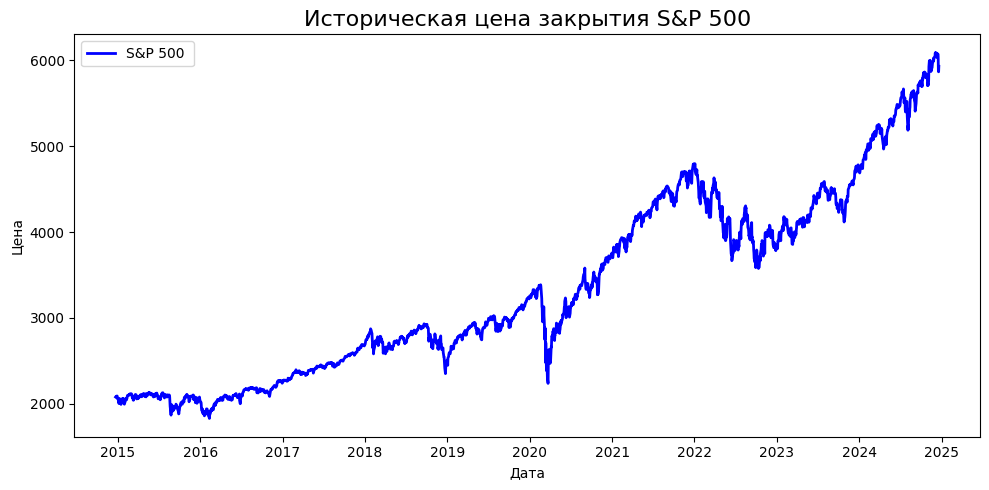

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(index_df['Date'], index_df['S&P500'], label='S&P 500 ', color='blue', linewidth=2)
plt.title('Историческая цена закрытия S&P 500', fontsize=16)
plt.xlabel('Дата')
plt.ylabel('Цена')
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()

График цены S&P 500 демонстрирует устойчивый восходящий тренд с 2014 по 2024 год. Отчетливо видны: резкое падение в начале 2020 года (COVID-19), восстановление во второй половине 2020-2021, и снижение в 2022 году на фоне инфляции и повышения ставок ФРС. Наличие тренда указывает на нестационарность ряда цен — необходимо переходить к доходностям для дальнейшего анализа.

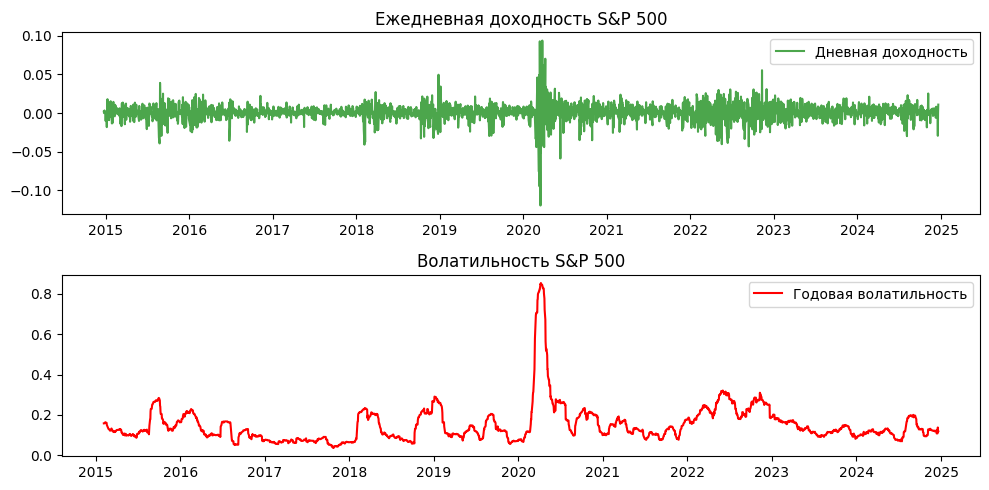

In [8]:
index_df['Vol_30'] = index_df['Return'].rolling(30).std() * np.sqrt(252)

fig, ax = plt.subplots(2, 1, figsize=(10, 5))
ax[0].plot(index_df['Date'], index_df['Return'], label='Дневная доходность', color='green', alpha=0.7)
ax[0].set_title('Ежедневная доходность S&P 500')
ax[0].legend()
ax[0].grid(False)

ax[1].plot(index_df['Date'], index_df['Vol_30'], label='Годовая волатильность', color='red')
ax[1].set_title('Волатильность S&P 500')
ax[1].legend()
ax[1].grid(False)
plt.tight_layout()
plt.show()

На верхнем графике видна кластеризация волатильности — периоды больших колебаний доходностей сменяются периодами затишья. Особенно выделяются: высокая волатильность в 2020 и в 2022 году.

Нижний график количественно подтверждает: годовая волатильность достигала 80% в кризисные периоды и опускалась до 10-15% в спокойные времена.

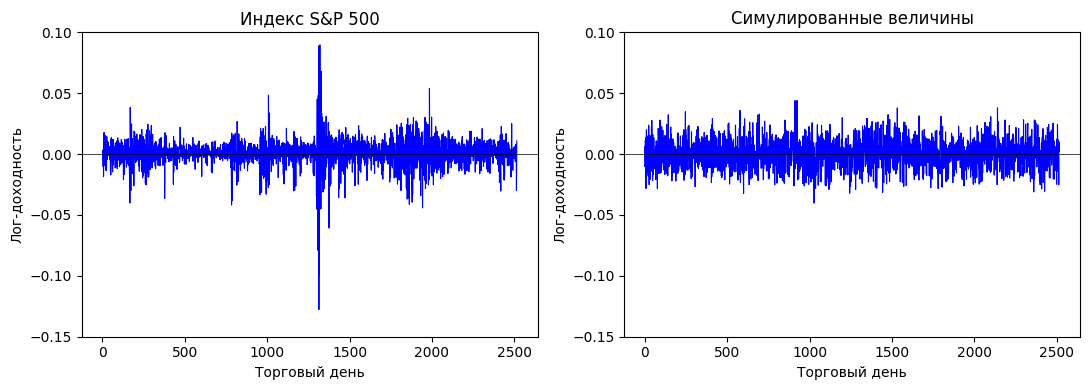

In [9]:
index_df['LogReturn'] = np.log(index_df['S&P500'] / index_df['S&P500'].shift(1))
log_returns = index_df['LogReturn'].dropna().values
mean_ret = log_returns.mean()
std_ret = log_returns.std()

simulated_normal = np.random.normal(mean_ret, std_ret, len(log_returns))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].plot(log_returns, color='blue', linewidth=0.8)
ax[0].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax[0].set_title('Индекс S&P 500', fontsize=12)
ax[0].set_xlabel('Торговый день')
ax[0].set_ylabel('Лог-доходность')
ax[0].set_ylim(-0.15, 0.10)

ax[1].plot(simulated_normal, color='blue', linewidth=0.8)
ax[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax[1].set_title('Симулированные величины', fontsize=12)
ax[1].set_xlabel('Торговый день')
ax[1].set_ylabel('Лог-доходность')
ax[1].set_ylim(-0.15, 0.10)

plt.tight_layout()
plt.show()

Сравним реальные логарифмические доходности индекса S&P 500 и симулированные нормальные случайные величины с теми же средним и дисперсией.
Характер графиков качественно отличается, что говорит о том, что распределение приращений значения индекса не является нормальным.

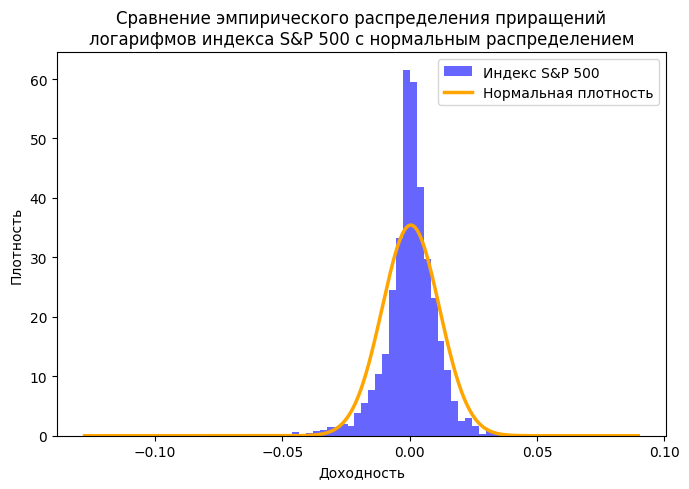

Коэффициент асимметрии: -0.8111
Коэффициент эксцесса: 15.7634


In [12]:
skewness = stats.skew(log_returns)
kurtosis_val = stats.kurtosis(log_returns, fisher=True)

plt.figure(figsize=(7, 5))

plt.hist(log_returns, bins=80, density=True, alpha=0.6, color='blue', label='Индекс S&P 500',
         edgecolor=None)

x = np.linspace(log_returns.min(), log_returns.max(), 1000)
normal_pdf = stats.norm.pdf(x, mean_ret, std_ret)
plt.plot(x, normal_pdf, color='orange', linewidth=2.5, label='Нормальная плотность')

plt.xlabel('Доходность')
plt.ylabel('Плотность')
plt.title('Сравнение эмпирического распределения приращений\nлогарифмов индекса S&P 500 с нормальным распределением', fontsize=12)
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()

print(f"Коэффициент асимметрии: {skewness:.4f}")
print(f"Коэффициент эксцесса: {kurtosis_val:.4f}")

Ненормальность распределения подтверждается и гистограммой.
Если бы данные были нормальными, то гистограмма была бы близка к графику
плотности нормального распределения, но видно, что их формы отличаются.
Отрицательность коэффициента асимметрии говорит о том, что распределение скошено влево, а положительность коэффициента эксцесса — о том, что распределение имеет более «тяжелые» хвосты по сравнению с нормальным распределением.

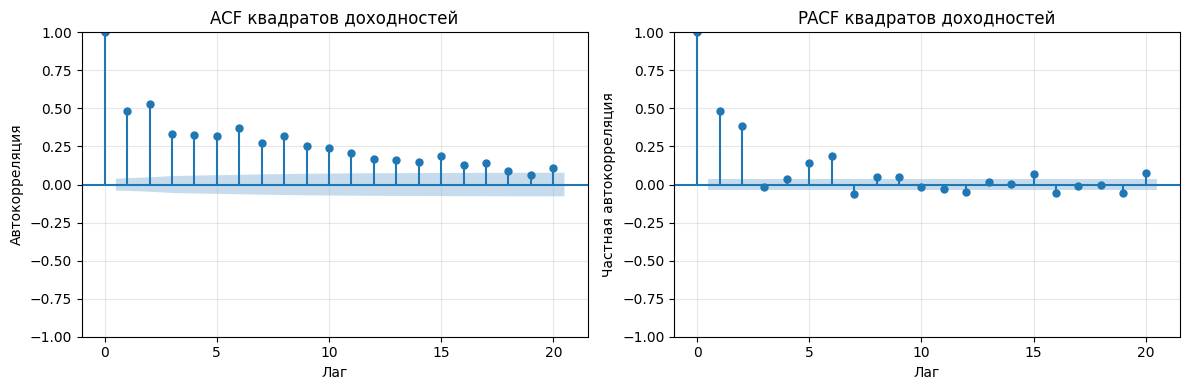

In [10]:

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
log_returns_sq = log_returns ** 2

plot_acf(log_returns_sq, lags=20, ax=ax[0], alpha=0.05)
ax[0].set_title('ACF квадратов доходностей', fontsize=12)
ax[0].set_xlabel('Лаг')
ax[0].set_ylabel('Автокорреляция')
ax[0].grid(True, alpha=0.3)

plot_pacf(log_returns_sq, lags=20, ax=ax[1], alpha=0.05)
ax[1].set_title('PACF квадратов доходностей', fontsize=12)
ax[1].set_xlabel('Лаг')
ax[1].set_ylabel('Частная автокорреляция')
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Анализ автокорреляционной функции квадратов доходностей показывает значимую автокорреляцию на первых лагах, выходящую за пределы 95% доверительного интервала. Это свидетельствует о наличии ARCH-эффектов. Медленное затухание ACF и значимость первых лагов PACF указывают на то, что для моделирования волатильности подходит модель GARCH(1,1).

<Figure size 800x500 with 0 Axes>

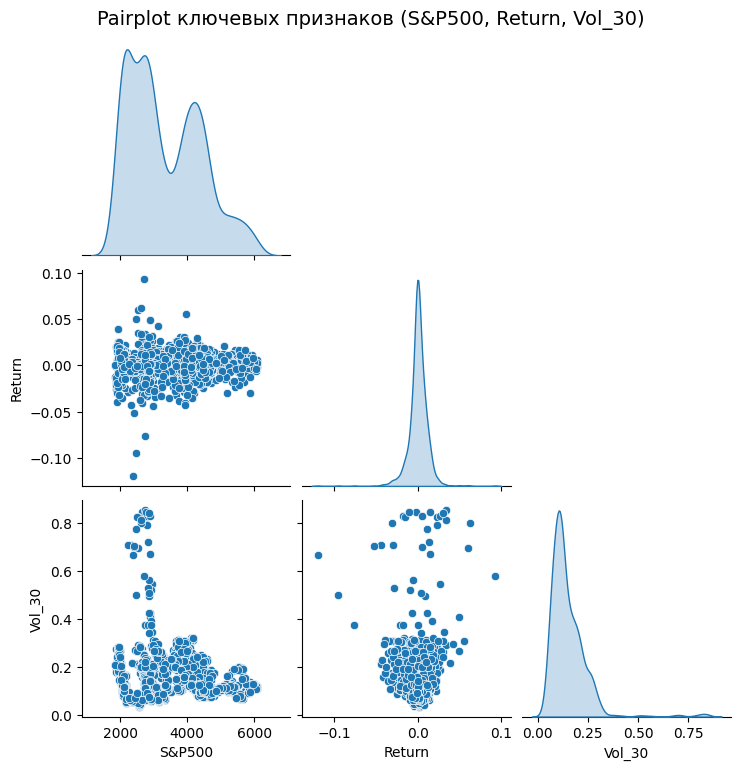

In [14]:
index_df['Vol_30'] = index_df['Return'].rolling(30).std() * np.sqrt(252)

subset_for_pairplot = index_df[['S&P500', 'Return', 'Vol_30']].dropna().sample(2000, random_state=42)

plt.figure(figsize=(8, 5))
sns.pairplot(subset_for_pairplot, diag_kind='kde', corner=True)
plt.suptitle('Pairplot ключевых признаков (S&P500, Return, Vol_30)', y=1.02, fontsize=14)
plt.show()

Pairplot показывает взаимосвязи между ценой, доходностью и волатильностью:

Между ценой и волатильностью наблюдается обратная зависимость — при падении цены волатильность растет (эффект рычага)

Доходность и волатильность: в периоды высокой волатильности разброс доходностей увеличивается

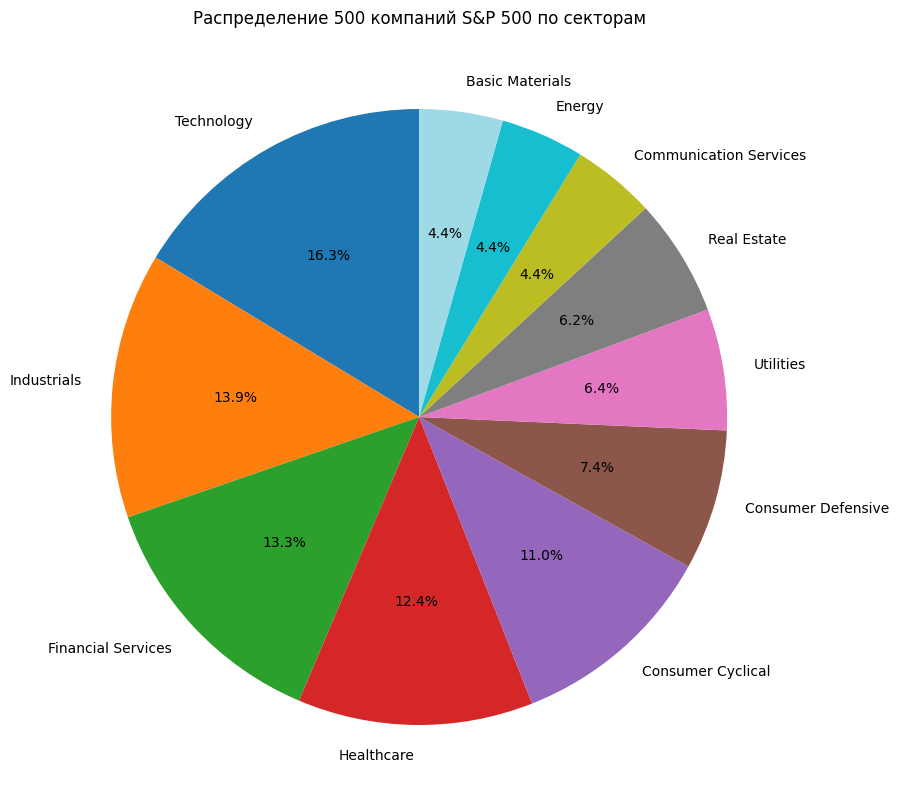

In [ ]:
plt.figure(figsize=(10, 10))
companies_df['Sector'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, cmap='tab20')
plt.title('Распределение 500 компаний S&P 500 по секторам')
plt.ylabel('')
plt.show()

Диаграмма показывает структуру индекса S&P 500 по секторам экономики. Наибольшую долю занимают сектора: Technology, Financials, Healthcare. Это важно для понимания, какие отрасли оказывают наибольшее влияние на динамику индекса. Доминирование технологического сектора означает, что волатильность S&P 500 сильно зависит от tech-компаний.

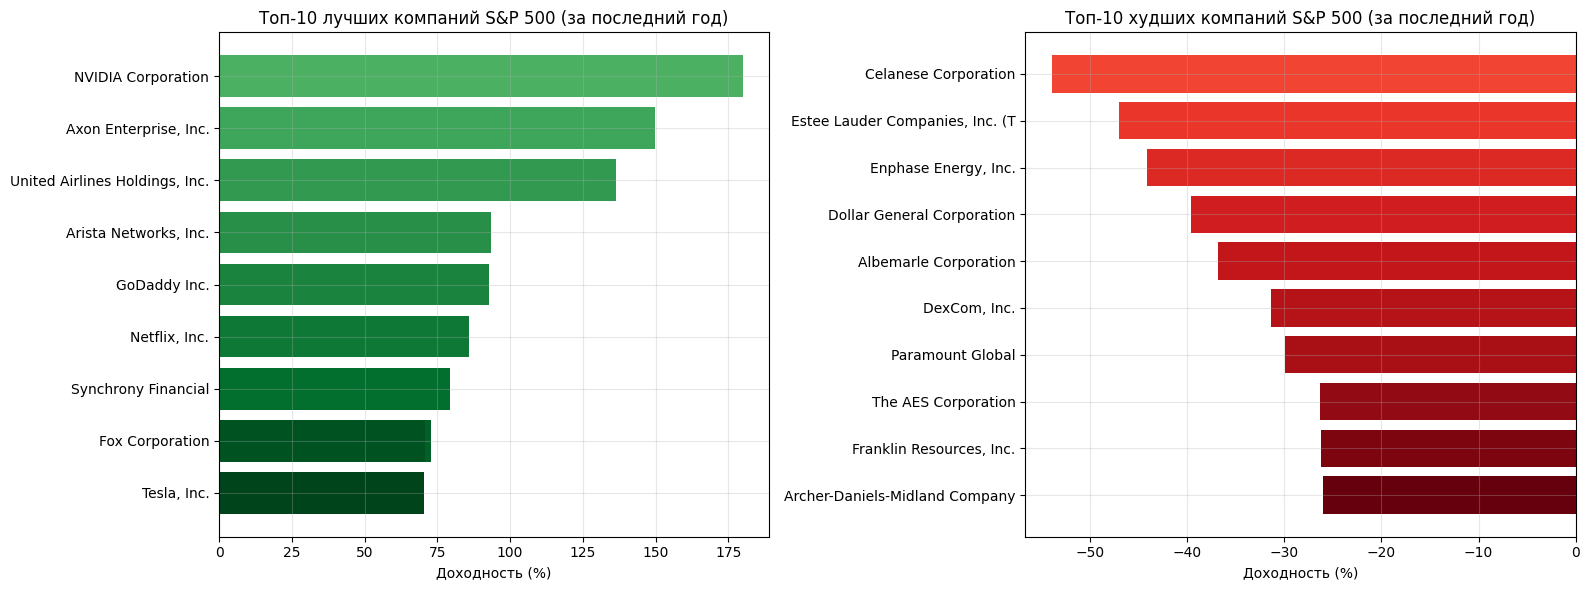

In [ ]:
stocks_df['Date'] = pd.to_datetime(stocks_df['Date'])
#Создаем словарь для сопоставления символов и названий
symbol_to_name = dict(zip(companies_df['Symbol'], companies_df['Shortname']))

#Фильтруем данные за последний год
latest_date = stocks_df['Date'].max()
one_year_ago = latest_date - pd.DateOffset(years=1)
recent_stocks = stocks_df[stocks_df['Date'] >= one_year_ago].copy()

stock_returns = recent_stocks.groupby('Symbol').apply(
    lambda x: (x['Adj Close'].iloc[-1] / x['Adj Close'].iloc[0] - 1) * 100
).reset_index(name='Total_Return')


stock_returns = stock_returns[stock_returns['Total_Return'].notna()]

stock_returns['Name'] = stock_returns['Symbol'].map(symbol_to_name)
stock_returns = stock_returns.dropna(subset=['Name'])

top_performers = stock_returns.nlargest(10, 'Total_Return')
worst_performers = stock_returns.nsmallest(10, 'Total_Return')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

bars1 = axes[0].barh(top_performers['Name'], top_performers['Total_Return'],
                     color=plt.cm.Greens(np.linspace(0.6, 1, 10)))
axes[0].set_title('Топ-10 лучших компаний S&P 500 (за последний год)', fontsize=12)
axes[0].set_xlabel('Доходность (%)')
axes[0].grid(True, alpha=0.3)

bars2 = axes[1].barh(worst_performers['Name'], worst_performers['Total_Return'],
                     color=plt.cm.Reds(np.linspace(0.6, 1, 10)))
axes[1].set_title('Топ-10 худших компаний S&P 500 (за последний год)', fontsize=12)
axes[1].set_xlabel('Доходность (%)')
axes[1].grid(True, alpha=0.3)

axes[0].invert_yaxis()
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

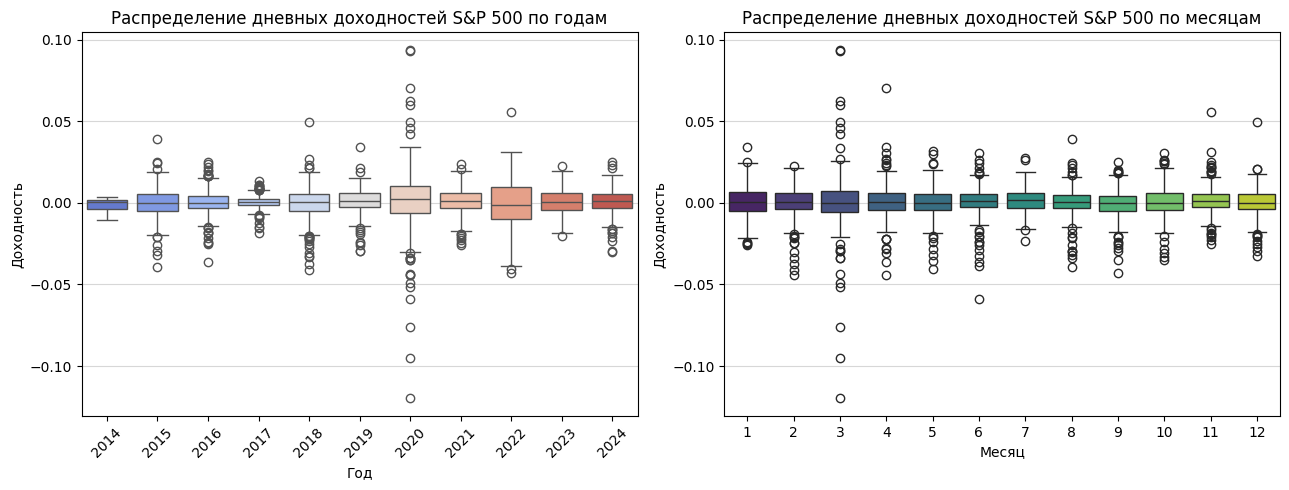

In [ ]:
index_df_clean = index_df.dropna(subset=['Return']).copy()
index_df_clean['Year'] = index_df_clean['Date'].dt.year
index_df_clean['Month'] = index_df_clean['Date'].dt.month

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(x='Year', y='Return', data=index_df_clean, ax=axes[0], palette='coolwarm')
axes[0].set_title('Распределение дневных доходностей S&P 500 по годам')
axes[0].set_ylabel('Доходность')
axes[0].set_xlabel('Год')
axes[0].grid(True, axis='y', alpha=0.5)
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(x='Month', y='Return', data=index_df_clean, ax=axes[1], palette='viridis')
axes[1].set_title('Распределение дневных доходностей S&P 500 по месяцам')
axes[1].set_ylabel('Доходность')
axes[1].set_xlabel('Месяц')
axes[1].grid(True, axis='y', alpha=0.5)

plt.tight_layout()
plt.show()

Анализ показал, что доходности индекса S&P 500 имеют медиану, близкую к нулю, во все рассматриваемые периоды, что соответствует гипотезе эффективного рынка. Однако наблюдается существенная изменчивость дисперсии по годам, особенно в кризисные периоды (2020 год), что свидетельствует о наличии гетероскедастичности и кластеризации волатильности.

Анализ по месяцам выявил, что наибольшее количество выбросов сосредоточено в марте

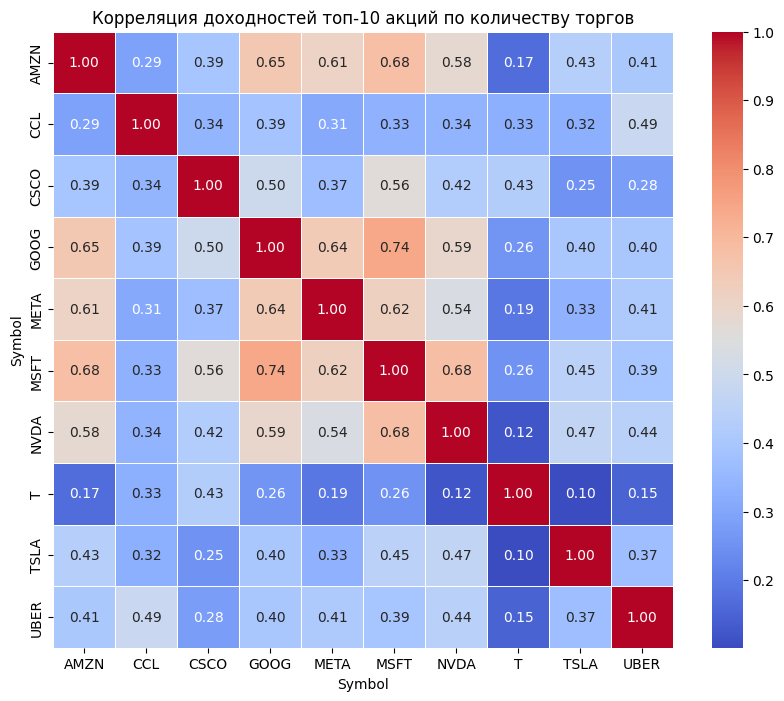

In [ ]:
recent = stocks_df[stocks_df['Date'] >= '2020-01-01'].copy()
recent['Return'] = recent.groupby('Symbol')['Adj Close'].pct_change()

top_symbols = recent.groupby('Symbol')['Volume'].sum().nlargest(10).index
corr_matrix = recent[recent['Symbol'].isin(top_symbols)] \
    .pivot_table(index='Date', columns='Symbol', values='Return').corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Корреляция доходностей топ-10 акций по количеству торгов')
plt.show()

Корреляционная матрица показывает высокую положительную корреляцию (0.6-0.74) между доходностями акций S&P 500. Это означает, что акции движутся синхронно: когда падает одна, падают и другие.

Высокая корреляция:

1) подтверждает наличие системного рыночного риска

2) обосновывает анализ индекса как единого актива

3) объясняет, почему волатильность индекса отражает общий уровень рыночного риска



### Выбор моделей
Планируется использовать модели семейства GARCH (Generalized Autoregressive Conditional Heteroskedasticity). Данный класс моделей позволяет описывать такие эмпирические особенности финансовых временных рядов, как кластеризация волатильности и изменяющаяся во времени условная дисперсия.

### Обоснование выбора моделей

Рассматриваются 3 спецификации GARCH-моделей:
- GARCH(1,1) с нормальным распределением — базовая модель, используемая в качестве эталона для сравнения
- GARCH(1,1) с t-распределением Стьюдента — позволяет учитывать «тяжелые хвосты» распределения доходностей, характерные для финансовых данных
- EGARCH(1,1) — экспоненциальная GARCH, моделирующая асимметричную реакцию волатильности на положительные и отрицательные шоки (эффект рычага)

### Обучения моделей

Обучение GARCH-моделей выполняется методом максимального правдоподобия.


# **Реализация**

In [32]:
#Разделение данных
train_size = int(len(returns) * 0.8)
returns_train = returns[:train_size]
returns_test = returns[train_size:]

#Обучение моделей
model_normal = arch_model(returns_train, vol='Garch', p=1, q=1, dist='normal')
model_normal_fit = model_normal.fit(disp='off')

model_t = arch_model(returns_train, vol='Garch', p=1, q=1, dist='studentst')
model_t_fit = model_t.fit(disp='off')

model_egarch = arch_model(returns_train, vol='EGARCH', p=1, q=1, o=1, dist='studentst')
model_egarch_fit = model_egarch.fit(disp='off')

#Сравнение по AIC/BIC
print("Сравнение информационных критериев:")
print(f"GARCH normal  — AIC: {model_normal_fit.aic:.2f}, BIC: {model_normal_fit.bic:.2f}")
print(f"GARCH t       — AIC: {model_t_fit.aic:.2f}, BIC: {model_t_fit.bic:.2f}")
print(f"EGARCH        — AIC: {model_egarch_fit.aic:.2f}, BIC: {model_egarch_fit.bic:.2f}")

Сравнение информационных критериев:
GARCH normal  — AIC: 5247.29, BIC: 5269.72
GARCH t       — AIC: 5093.80, BIC: 5121.83
EGARCH        — AIC: 5024.14, BIC: 5057.78


На основе информационных критериев лучшей оказалась модель EGARCH(1,1). После обучения модели важно проверить, насколько хорошо она справляется с моделированием волатильности. Для этого анализируем стандартизированные остатки:

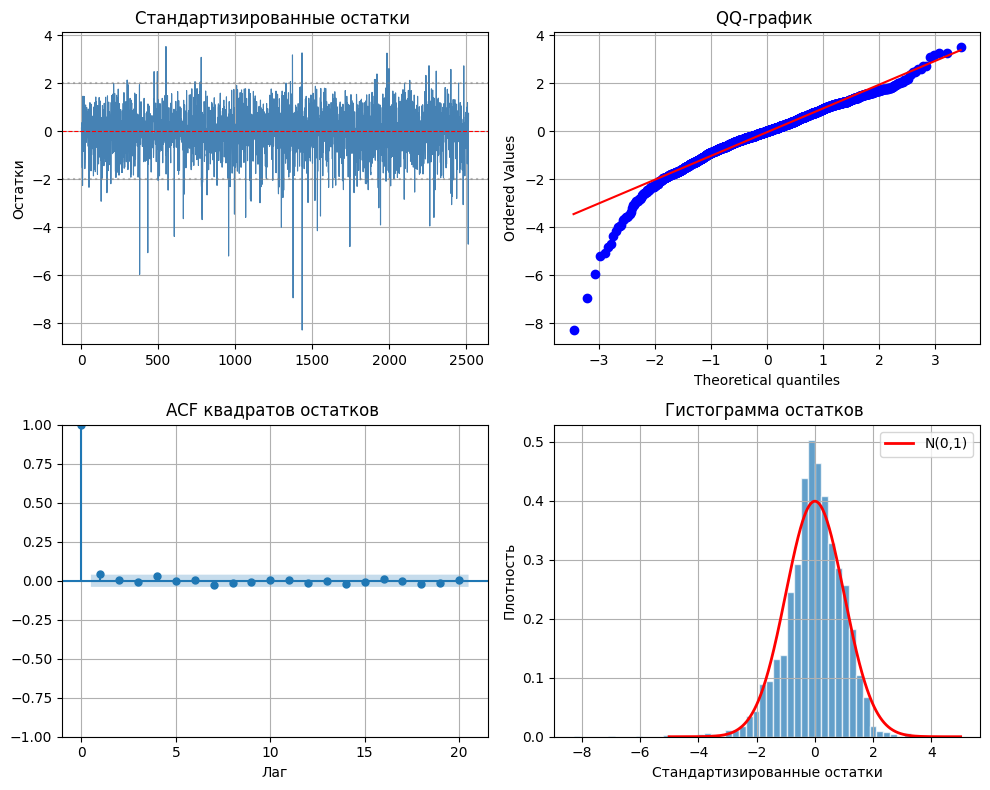

In [18]:
resid_eg = model_egarch_fit.resid
cond_vol_eg = model_egarch_fit.conditional_volatility
mask_eg = ~np.isnan(resid_eg) & ~np.isnan(cond_vol_eg)
std_resid_eg = resid_eg[mask_eg] / cond_vol_eg[mask_eg]

fig, ax = plt.subplots(2, 2, figsize=(10, 8))

ax[0, 0].plot(std_resid_eg, linewidth=0.8, color='steelblue')
ax[0, 0].axhline(y=0, color='red', linestyle='--', linewidth=0.8)
ax[0, 0].axhline(y=2, color='gray', linestyle=':', alpha=0.5)
ax[0, 0].axhline(y=-2, color='gray', linestyle=':', alpha=0.5)
ax[0, 0].set_title('Стандартизированные остатки ')
ax[0, 0].set_ylabel('Остатки')
ax[0, 0].grid(True)

stats.probplot(std_resid_eg, dist='norm', plot=ax[0, 1])
ax[0, 1].set_title('QQ-график ')
ax[0, 1].grid(True)

plot_acf(std_resid_eg**2, lags=20, ax=ax[1, 0])
ax[1, 0].set_title('ACF квадратов остатков ')
ax[1, 0].set_xlabel('Лаг')
ax[1, 0].grid(True)

ax[1, 1].hist(std_resid_eg, bins=50, alpha=0.7, density=True, edgecolor='white')
x = np.linspace(-5, 5, 1000)
ax[1, 1].plot(x, stats.norm.pdf(x, 0, 1), 'r', lw=2, label='N(0,1)')
ax[1, 1].set_title('Гистограмма остатков ')
ax[1, 1].set_xlabel('Стандартизированные остатки')
ax[1, 1].set_ylabel('Плотность')
ax[1, 1].legend()
ax[1, 1].grid(True)

plt.tight_layout()
plt.show()

QQ-график сравнивает квантили стандартизированных остатков с теоретическими квантилями нормального распределения. В центре распределения точки близки к диагональной линии, что говорит о хорошем соответствии основной массы данных.

ACF квадратов остатков показывает автокорреляцию квадратов стандартизированных остатков на разных лагах. Все столбики находятся в пределах доверительного интервала (синяя область), что означает отсутствие статистически значимой автокорреляции.

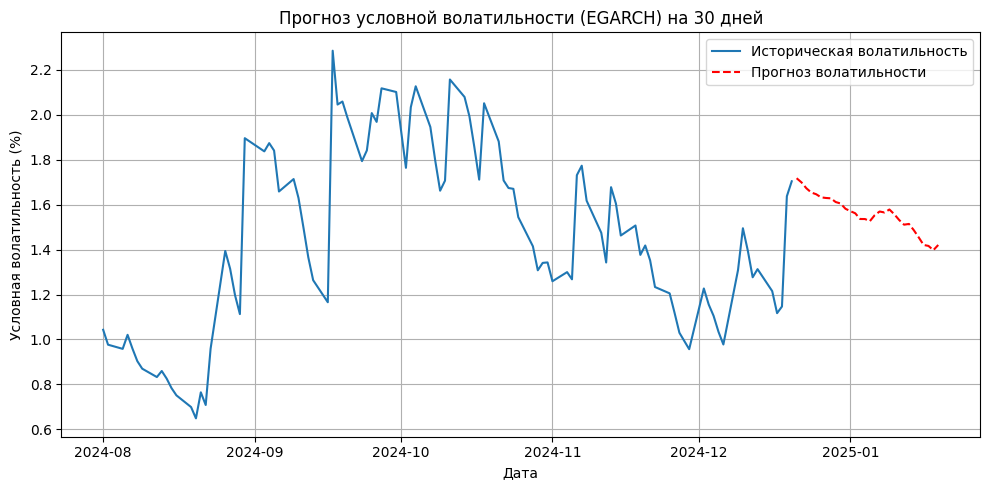


Прогноз волатильности на ближайшие дни:
2024-12-21: 1.7176%
2024-12-22: 1.6990%
2024-12-23: 1.6728%
2024-12-24: 1.6540%
2024-12-25: 1.6465%

Долгосрочный прогноз волатильности (через 30 дней): 1.4205%


In [76]:
#Выбор лучшей модели
best_model = model_egarch_fit

#Прогнозирование на 30 дней вперед
np.random.seed(42)
forecasts = best_model.forecast(horizon=forecast_horizon, method='simulation')
forecast_horizon = 30
forecasts = best_model.forecast(horizon=forecast_horizon, method='simulation')

#Извлечение прогнозов волатильности
forecast_variance = forecasts.variance.iloc[-1].values
forecast_volatility = np.sqrt(forecast_variance)

plt.figure(figsize=(10, 5))
plt.plot(data.index[-100:], best_model.conditional_volatility[-100:], label='Историческая волатильность')
last_date = data.index[-1]
forecast_dates = pd.date_range(start=last_date, periods=forecast_horizon + 1)[1:]
plt.plot(forecast_dates, forecast_volatility, 'r--', label='Прогноз волатильности')
plt.title('Прогноз условной волатильности (EGARCH) на 30 дней')
plt.xlabel('Дата')
plt.ylabel('Условная волатильность (%)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("\nПрогноз волатильности на ближайшие дни:")
for i, (date, vol) in enumerate(zip(forecast_dates[:5], forecast_volatility[:5])):
    print(f"{date.date()}: {vol:.4f}%")

print(f"\nДолгосрочный прогноз волатильности (через {forecast_horizon} дней): {forecast_volatility[-1]:.4f}%")

Модель EGARCH не позволяет получить аналитический прогноз на несколько шагов вперед из-за нелинейности уравнения (экспонента и модуль), поэтому прогноз на 30 дней выполнен методом Монте-Карло.

In [77]:
# Сравнение MSE/QLIKE
actual_var = returns_test**2

models = {
    'GARCH normal': model_normal_fit,
    'GARCH t': model_t_fit,
    'EGARCH': model_egarch_fit
}
np.random.seed(42)
for name, model in models.items():
    if 'EGARCH' in name:
        forecast = model.forecast(horizon=len(returns_test), method='simulation')
    else:
        forecast = model.forecast(horizon=len(returns_test))
    pred_var = forecast.variance.iloc[-1].values

    mse = np.mean((pred_var - actual_var)**2)
    qlike = np.mean(np.log(pred_var) + actual_var / pred_var)
    print(f"{name:<15} — MSE: {mse:.4f}, QLIKE: {qlike:.4f}")

GARCH normal    — MSE: 2.8346, QLIKE: 1.0162
GARCH t         — MSE: 53.0439, QLIKE: 1.9939
EGARCH          — MSE: 1.4112, QLIKE: 0.6985


Из трёх рассмотренных моделей (GARCH(1,1) normal, GARCH(1,1) t, EGARCH(1,1) t) наилучшей по совокупности критериев оказалась EGARCH. Модель имеет минимальные AIC и BIC, а также показала наилучшее качество прогноза на тестовой выборке (MSE = 1.41, QLIKE = 0.69).